# 一、Retrieval-Augmented Generation (RAG) 介绍

## 1. 什么是 RAG？
RAG（Retrieval-Augmented Generation）是一种结合了 **信息检索（Retrieval）** 和 **文本生成（Generation）** 的AI技术框架。它的核心思想是，在生成文本时，不仅依赖于模型本身的参数，还可以从外部知识库中检索相关的信息，以增强生成的内容。

## 2. RAG 的工作原理
RAG 主要包括两个阶段：
1. **检索（Retrieval）**：从知识库（如文档、数据库、互联网等）中检索出与输入问题最相关的内容。
2. **生成（Generation）**：利用检索到的信息作为额外的上下文输入，引导大语言模型（如GPT）生成更准确、更可靠的答案。

<span style="color: red;font-size:16px">其流程如下：</span>
- 用户输入查询（Query）
- 通过向量数据库（如 FAISS、ChromaDB、Milvus）检索相关文档
- 将检索到的文档作为上下文，输入到 LLM（如 Qwen、GPT-4）
- 生成增强后的回答

**基础版RAG流程如下**
# <span style="color: red;font-size:16px">来了一个问题，根据问题去图书馆查，查到答案根据答案回答问题</span>

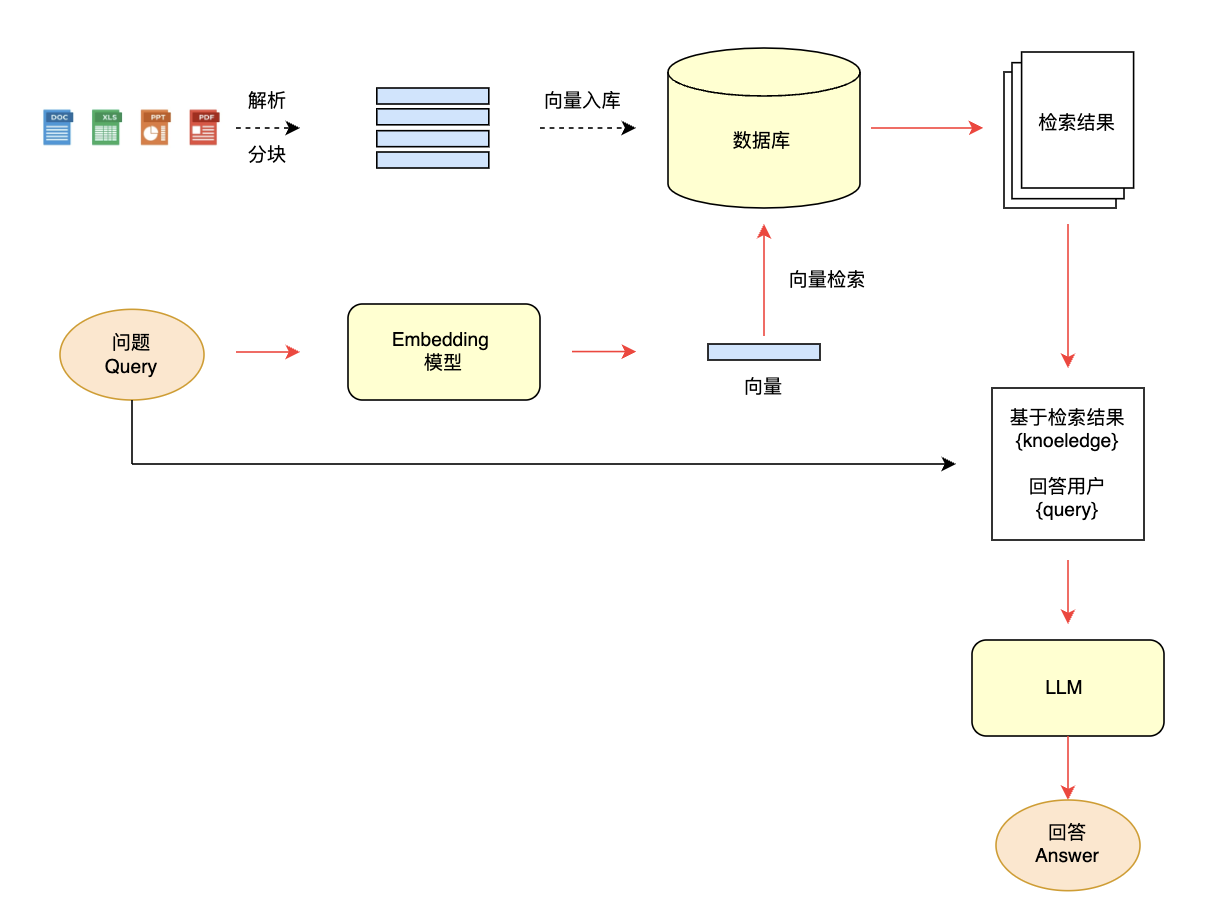

### 我们来看一下向量相似度度的定义

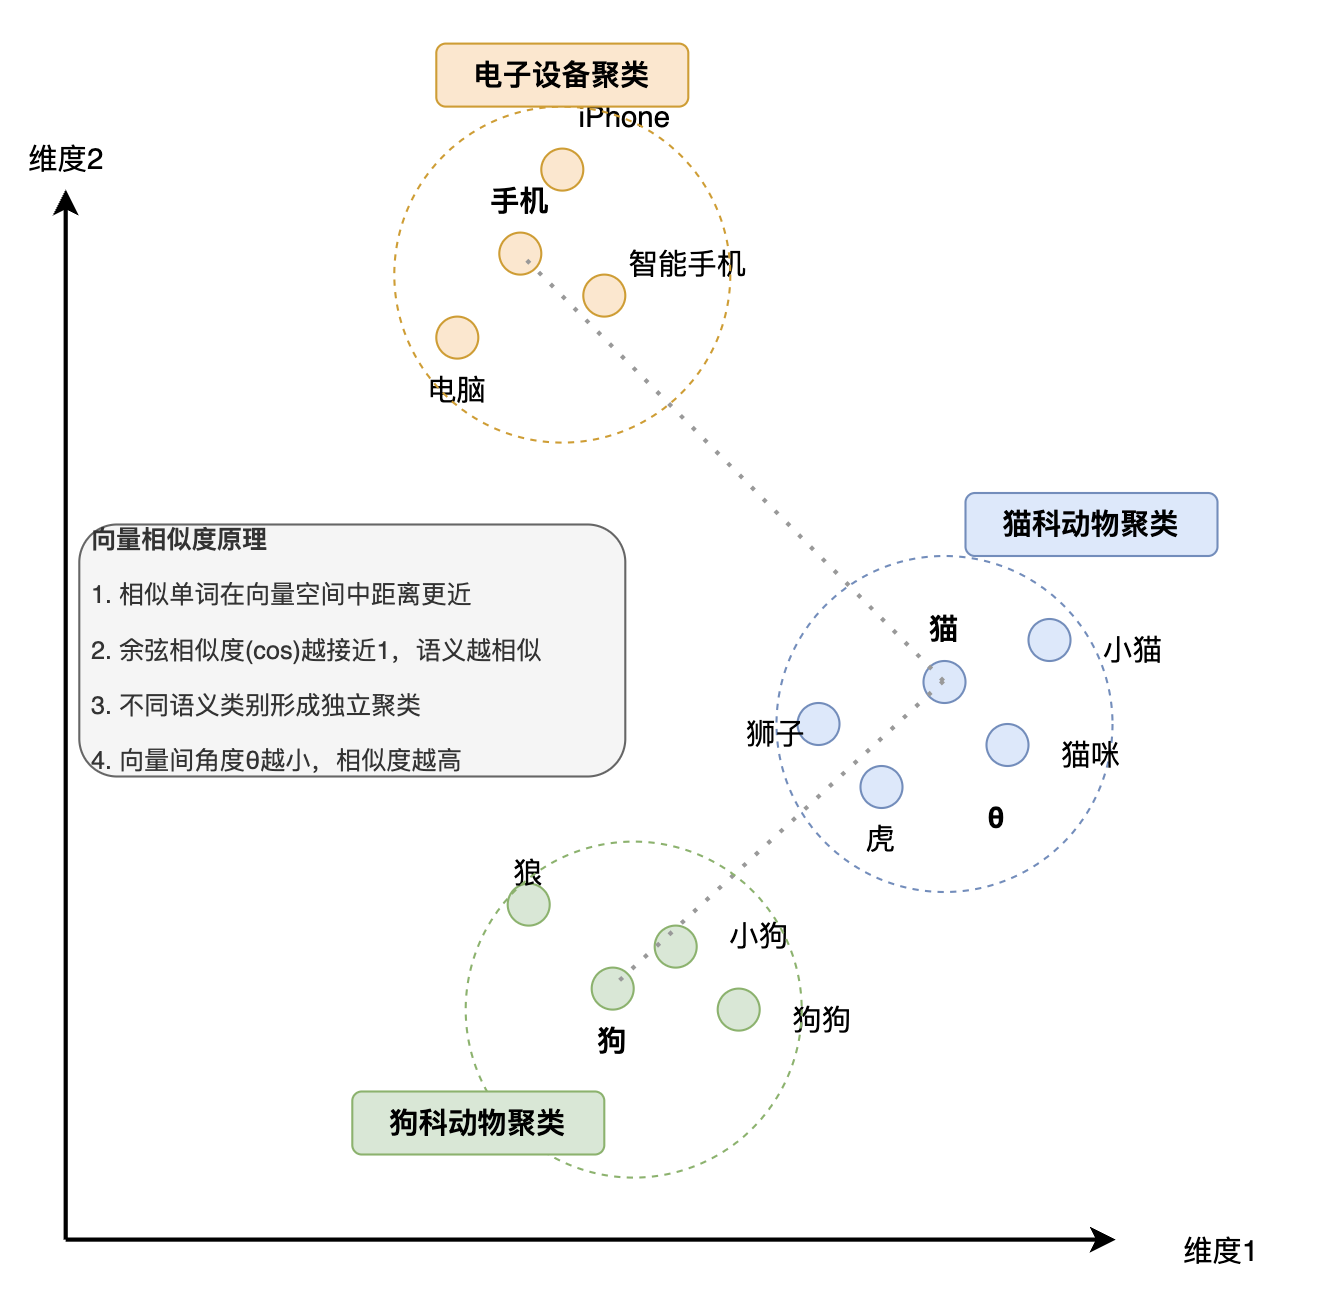

余弦相似度（Cosine Similarity）用于衡量两个向量在多维空间中的夹角余弦值，其公式如下：

$$[
\text{Cosine Similarity} = \cos(\theta) = \frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\| \|\mathbf{B}\|}
]$$

其中：
- $$(\mathbf{A} \cdot \mathbf{B}) 表示向量 (\mathbf{A}) 和 (\mathbf{B}) 的点积：
  [
  \mathbf{A} \cdot \mathbf{B} = \sum_{i=1}^{n} A_i B_i
  ]$$
- $$(|\mathbf{A}\|) 和 (|\mathbf{B}\|) 分别表示向量的欧几里得范数（即向量的模）：
  [
  |\mathbf{A}\| = \sqrt{\sum_{i=1}^{n} A_i^2}, \quad \|\mathbf{B}\| = \sqrt{\sum_{i=1}^{n} B_i^2}
  ]$$

余弦相似度的取值范围为 \([-1,1]\)：
- 当值接近 1 时，表示两个向量方向相似（夹角接近 0°）。
- 当值接近 0 时，表示两个向量接近正交（夹角接近 90°）。
- 当值接近 -1 时，表示两个向量方向相反（夹角接近 180°）。

在文本分析、推荐系统和信息检索中，余弦相似度常用于衡量文档或用户偏好的相似程度。

## 3. 为什么使用 RAG？
RAG 具有以下优势：
- **动态更新知识**：相比纯 LLM 依赖训练后的参数，RAG 可从外部知识库获取最新信息，无需重新训练模型。
- **提高生成质量**：减少幻觉（Hallucination）问题，使生成内容更加准确和可解释。
- **本地数据的隐私性**：很对企业数据是不能上传云端，或者进行模型训练的
# <span style="color: red;font-size:16px">还有一个LLM本身的问题是什么？</span>

## 4. RAG 的应用场景
RAG 适用于各种需要动态知识更新的 NLP 任务，包括但不限于：
- **智能问答**：结合企业文档库，实现精准的企业内部问答系统。
- **法律和医学咨询**：结合法律法规、医学文献，提供更可靠的专业回答。
- **代码生成与修复**：结合代码文档、技术文档，增强代码生成的准确性。
- **企业/个人知识库问答**：

## 5. RAG 的核心技术组件
- **检索模块**：
  - 向量数据库（FAISS、Weaviate、ChromaDB）
  - 关键字搜索（Elasticsearch、BM25）
- **生成模型**：
  - 大语言模型（GPT-4、Qwen、LLaMA-2）
- **知识库**：
  - 结构化数据（数据库、知识图谱）
  - 非结构化数据（文档、网页、论坛）

# 二、用LlamaIndex构建基础款应用

## 1.什么是LlamaIndex

`LlamaIndex` 是一个用于 `LLM` 应用程序的数据框架，用于注入，结构化，并访问私有或特定领域数据。

`LlamaIndex` 由 Jerry Liu (Twitter: [@jerryjliu0](https://twitter.com/jerryjliu0)) 联合创办，并担任CEO。

## 2.LlamaIndex的优势？

<span style="color: red;font-size:16px">一言以蔽之：llamaindex是目前最适合做RAG的框架</span>

在本质上，`LLM`（如`GPT`）为人类和推断出的数据提供了基于自然语言的交互接口。广泛可用的大模型通常在大量公开可用的数据上进行的预训练，包括来自维基百科、邮件列表、书籍和源代码等。

构建在LLM模型之上的应用程序通常需要使用私有或特定领域数据来增强这些模型。不幸的是，这些数据可能分布在不同的应用程序和数据存储中。它们可能存在于API之后、SQL数据库中，或者存在在PDF文件以及幻灯片中。

LlamaIndex应运而生。

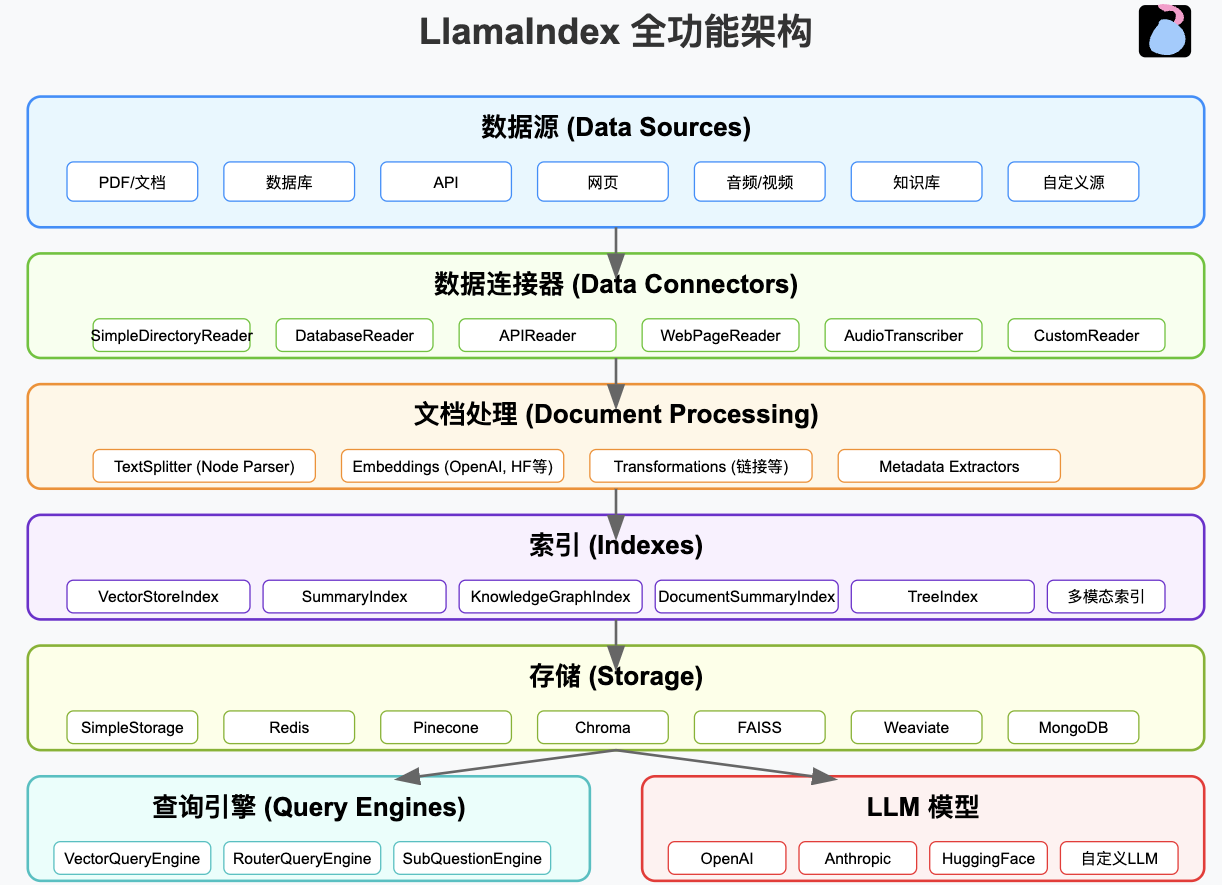
## 3.LlamaIndex核心功能？

`LlamaIndex` 提供了5大核心工具：
- **Data connectors（数据连接器）**：用于从各种数据源（如数据库、API、文件系统等）提取和加载数据，以便进行索引和查询。  
- **Data indexes（数据索引）**：负责组织和存储已提取的数据，以支持高效的信息检索和查询优化。  
- **Engines（引擎）**：执行查询处理、语义搜索、RAG（检索增强生成）等任务，确保数据的高效利用和交互。  
- **Data agents（数据代理）**：智能化的数据处理组件，可自动执行任务，如数据转换、合并、增强或基于上下文进行推理。  
- **Application integrations（应用集成）**：提供与外部应用（如LLMs、BI工具、SaaS平台等）的接口，确保数据与现有系统无缝交互。

![LlamaIndex核心工具](./01_2.png)

## 我们来看看这些功能在RAG的整理流程中扮演什么角色

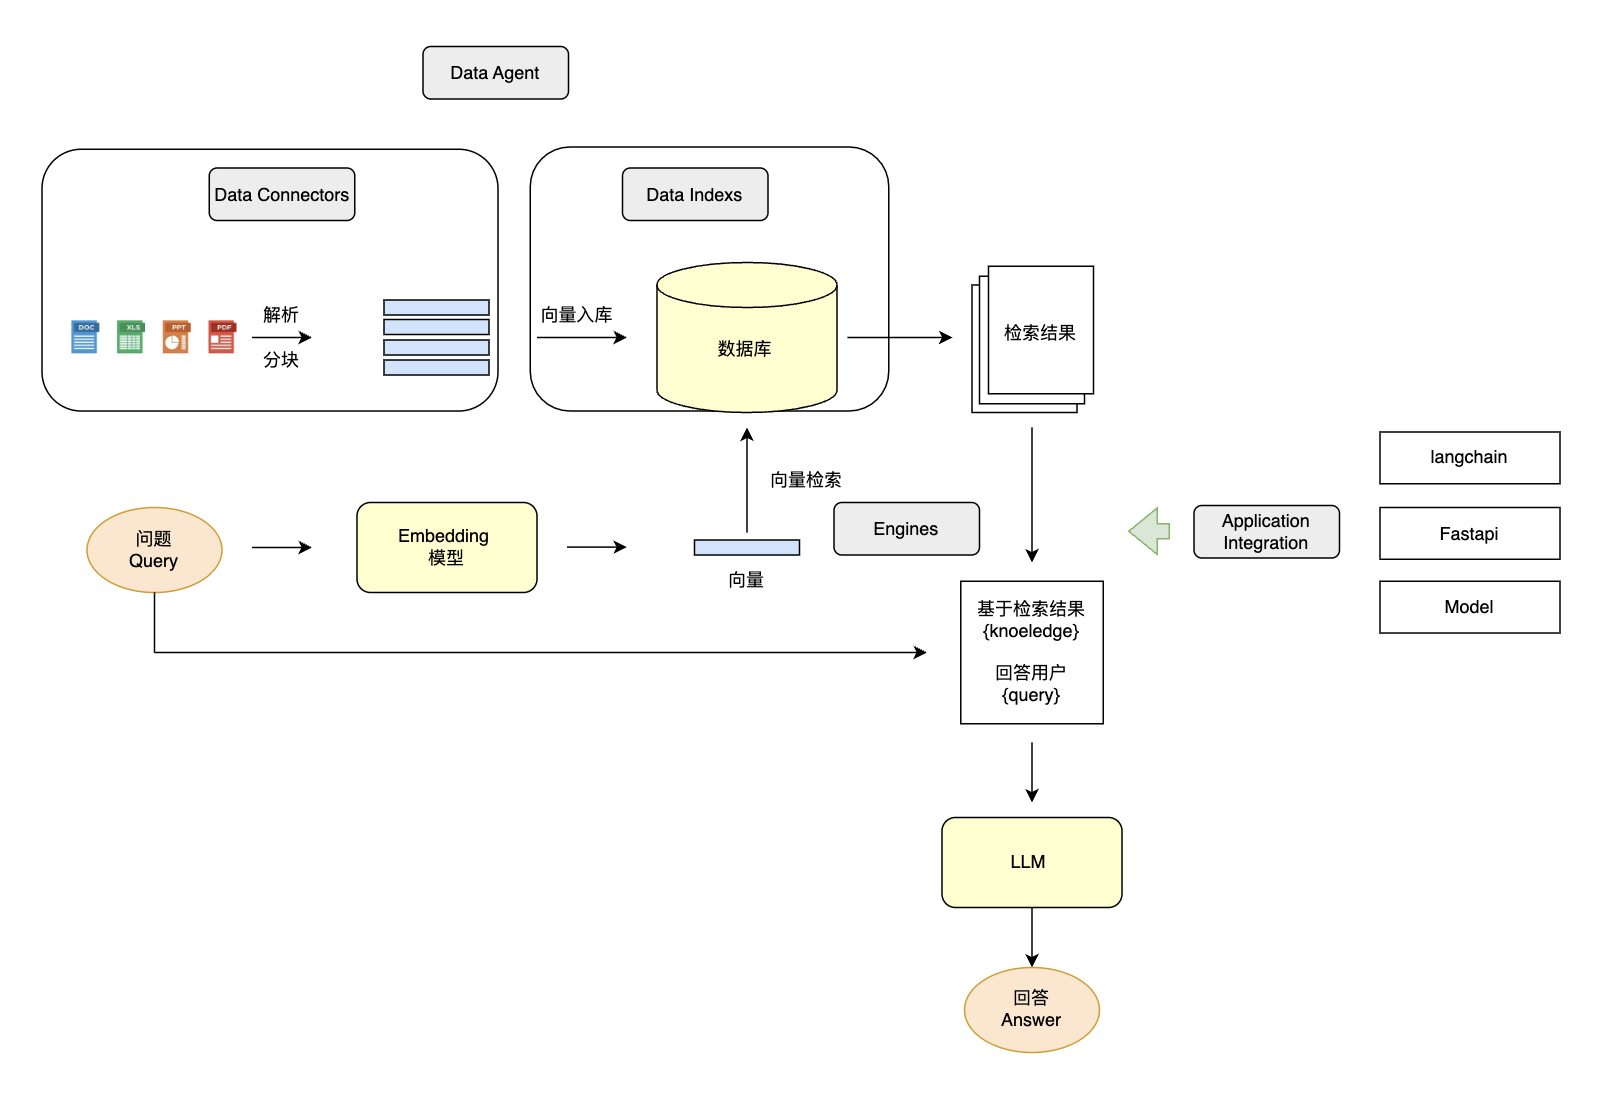

## 4.用llamindex 4行代码极速构建RAG应用

In [1]:
!pip install -q llama-index

In [27]:
import os
os.environ['OPENAI_API_KEY'] = ''

In [29]:
from llama_index.core import VectorStoreIndex, SimpleDirectoryReader

#步骤一，文档解析
documents = SimpleDirectoryReader('data').load_data()
#步骤二，构建索引
index = VectorStoreIndex.from_documents(documents)

In [6]:
#步骤三，构建查询引擎
query_engine = index.as_query_engine()
#步骤四，得到结果
response = query_engine.query("收盘价多少")
print(response)

The closing price is 36.37元.


In [35]:
response = query_engine.query("世运电路2023年同比增长")
print(response)

46.85%


In [69]:
response = query_engine.query("总结一下这篇文章，用中文")
print(response)

这篇文章主要是一份公司点评报告，包括了分析师声明、投资评级说明、信息披露以及使用本研究报告的风险提示及法律声明等内容。报告中提到了投资建议的评级标准，包括股票评级和行业评级，以及投资建议的具体说明。此外，报告还强调了信息披露的重要性，提醒客户在使用报告时应注意风险，并自主作出投资决策。文章最后指出了过往业绩表现不应作为日后回报的预示，投资者应谨慎对待回报预测。
